In [1]:
import os
import sys
import gc
os.chdir('/zhome/71/c/146676/texture_tomography')
import h5py
import numpy as np
from pathlib import Path

from diffractom.operators.pfo_single_material import PFO_SINGLE, estimate_L_power
from diffractom.operators.pfo_and_projection_batched_opencl import PFO_OPENCL_BATCHED

import matplotlib.pyplot as plt
from multiprocessing import Pool
import yaml

from diffractom.optimization.fista_opencl import FISTAOpenCL
from diffractom.optimization.fista_huber_opencl import FISTAHuberOpenCL
from diffractom.gpu_live_tracker import GPUMemoryLogger
from diffractom.operators.memory_tracker import MemoryCounter
import pyopencl.array as clarray
from diffractom.multiresolution_refiner import OrientationTree, invert_grid
from diffractom.material import Material
from scipy.spatial.transform import Rotation as R
from scipy.spatial.transform import Rotation as Rot
from diffractom.operators.create_pfo_matrix import pfmatrix_sparseeval_gpu,sparse_pf_innerprod_gpu,interp_theta_4d_gpu, interp_theta_3d_gpu, build_pfsparse_program, sum_over_x_gpu, clip_nonnegative_gpu
import pyopencl as cl

from orix import plot, sampling
from orix.crystal_map import Phase
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


In [2]:
config_path = "configs/aluminum_config_single_large.yaml"

with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)

N_eta = cfg['N_eta']
N_Omega = cfg['N_Omega']
N_theta = cfg['N_theta']
Nx = cfg['Nx']
Ny = cfg['Ny']
datapath = cfg["datapath"]
filename_integrated = cfg["integrated_file"]
cif_path = cfg["cif_path"]
cor_offset = cfg["cor_offset"]
wavelength_kev = cfg['wavelength']
min_two_theta = cfg['min_two_theta']
max_two_theta = cfg['max_two_theta']
reflection_cutoff = cfg['reflection_cutoff']
filename = datapath + filename_integrated

In [3]:
with h5py.File(filename, "r") as f:
    dset = f["I"]
    arr = np.empty(dset.shape, dtype=dset.dtype)
    dset.read_direct(arr)

In [4]:
arr = arr/arr.sum(axis=(0,1,2), keepdims = True)*arr.sum()*10
all_data_reshaped1 = arr.reshape((3000, Nx, N_eta*N_theta))
all_data_reshaped = all_data_reshaped1[::3000//N_Omega]/(3000//N_Omega)

for i in range(1,3000//N_Omega):
    all_data_reshaped += all_data_reshaped1[i::3000//N_Omega]/(3000//N_Omega)

In [5]:
cif_folder = Path(cif_path)
filenames = [p.name for p in cif_folder.glob("*.cif")]
N_mat = len(filenames)


path = cif_folder / filenames[0]
material = Material.from_cif(
    cif_path=path,
    wavelength_kev=wavelength_kev,
    min_two_theta=min_two_theta,
    max_two_theta=max_two_theta,
    intensity_cutoff_fraction=reflection_cutoff,
)




# create small initial grid to initialize the operator
rotations = np.eye(3)[None, :, :]
grid = OrientationTree.from_rotation_matrices(
    rotations,
    sigma=0.1,
)


two_theta = (material.reflections['two_theta'])

In [6]:
ctx = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
pf_prg = build_pfsparse_program(ctx)




op = PFO_SINGLE(
        cfg = cfg,
        material=material,
        grid=grid,
        max_gb=1.0,
        verbose=True,
        normalized = True,
        ctx = ctx,
        queue = queue)

kernel_pfmatrix_count_sparse = cl.Kernel(pf_prg, "pfmatrix_count_sparse")
kernel_pfmatrix_write_sparse = cl.Kernel(pf_prg, "pfmatrix_write_sparse")
kernel_sparse_pf_innerprod_4d = cl.Kernel(pf_prg, "sparse_pf_innerprod_4d")
kernel_interp3d = cl.Kernel(pf_prg, "interp_theta_3d")
kernel_interp4d = cl.Kernel(pf_prg, "interp_theta_4d")
kernel_sum_over_x = cl.Kernel(pf_prg, "sum_over_x")
kernel_clip_nonnegative = cl.Kernel(pf_prg, "clip_nonnegative")

out_cpu = np.ascontiguousarray(
    all_data_reshaped,
    dtype=np.float32
)
out_gpu = clarray.to_device(queue, out_cpu)

out_gpu = out_gpu.reshape((N_Omega, Nx, N_eta, N_theta))

0.3562848439565492
[0.15253486 0.17618918 0.24949357 0.29284424 0.3858888 ]

=== OpenCL buffer allocation summary ===
coeffs_sino_F                 : shape=(148x750x1),     0.42 MB
coeffs_sino_C                 : shape=(750x148x1),     0.42 MB
_coeffs_batch_F               : shape=(148x148x1),     0.08 MB
_basis_batch_kmax             : shape=(750x1x720x5),    10.30 MB
_basis_batch_transpose_kmax   : shape=(750x3600x1),    10.30 MB
_grid_inv_kmax                : shape=(1x9),     0.00 MB
_inv_sigma2_kmax              : shape=(1),     0.00 MB
_norm_factor_kmax             : shape=(1),     0.00 MB
---------------------------------------
TOTAL GPU buffer memory:    21.53 MB



In [7]:
grid_resolution_parameter = 39      # example
kernel_sigma = 0.01            # example
sigma_levels = [kernel_sigma]      # start with single level


# grid_fine = OrientationTree.from_hopf_fzone(
#     material.point_group_matrices,
#     grid_resolution_parameter=grid_resolution_parameter,
#     sigma_levels=sigma_levels,
# )

R_random = R.random(40000).as_matrix()   # shape (1000,3,3)
grid_fine = OrientationTree.from_rotation_matrices(
    R_random,
    sigma=0.02,
)

import h5py, hdf5plugin
with h5py.File("/work3/msaca/basis_set.h5", "r") as f:
    # Rotation matrices (shape: N, 3, 3) in Orix convention but as numpy array.
    good_orientations2 = f["numpy_orien"][...]

# import itertools
# perms = list(itertools.permutations([0,1,2]))
# P = np.eye(3)[list(perms[0])]
#     # coordinate-system transformed rotations
# mats = P @ good_orientations2[:] @ P.T
# grid_fine = OrientationTree.from_rotation_matrices(
#     mats,
#     sigma=0.01,
# )

In [8]:
def score_nodes(queue, grid_fine, op, node_indices, material, sigma, res_peaks_gpu_summed):
    rotations = [grid_fine.nodes[i].R for i in node_indices]
    grid_inv_cpu = invert_grid(rotations)
    grid_inv_gpu = clarray.to_device(queue, grid_inv_cpu)

    K = len(rotations)
    R = op.N_Omega
    C = op.N_eta
    P = op.N_peaks
    G = len(material.point_group_matrices)

    cutoff = 0.1 * 1.0 / (2*np.pi*sigma**2)

    sparse_pf = pfmatrix_sparseeval_gpu(
        queue,
        kernel_pfmatrix_count_sparse,
        kernel_pfmatrix_write_sparse,
        op.coords_gpu,
        grid_inv_gpu,
        op.sym_ops_gpu,
        op.h_gpu_normed,
        R, K, C, P, G,
        sigma,
        cutoff
    )

    IPs = sparse_pf_innerprod_gpu(
        queue,
        kernel_sparse_pf_innerprod_4d,
        sparse_pf,
        res_peaks_gpu_summed,
        R, C, P, K,
    )

    scores = IPs.get()
    scores = np.maximum(scores, 0)
    #scores /= (scores.max() + 1e-12)

    for local_k, node_idx in enumerate(node_indices):
        grid_fine.nodes[node_idx].score = float(scores[local_k])

    return scores

In [9]:
out_cpu_summed = out_cpu.mean(axis=1)
node_indices = grid_fine.active_leaf_nodes_at_level(0)

res_peaks_gpu_summed = clarray.to_device(op.queue, np.ascontiguousarray(out_cpu_summed, dtype=np.float32))


In [10]:
nodes_per_batch = 500

batches = [node_indices[i:i+nodes_per_batch] for i in range(0, len(node_indices), nodes_per_batch)]
scores = []
for i_batch in range(len(batches)):
    scores.append(score_nodes(queue, grid_fine, op, batches[i_batch], material, kernel_sigma, res_peaks_gpu_summed))

scores = np.concatenate(scores,axis=0)
print(scores.shape)

(40000,)


40000
(5000, 3, 3)
(20000, 3, 3)


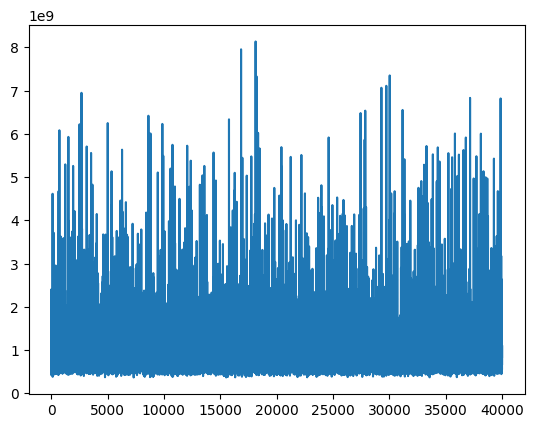

In [11]:
plt.plot(scores)
print(np.sum(scores>1.5e8))
good_indices = np.where(scores>1.5*1e8)[0]
good_orientations = np.stack([grid_fine.nodes[i].R.as_matrix() for i in good_indices])


import numpy as np
from scipy.spatial.transform import Rotation as R
from sklearn.neighbors import KDTree

def prune_rotations(Rmats, theta_deg, target=5000):
    # Convert to quaternions
    q = R.from_matrix(Rmats).as_quat()  # (x,y,z,w)
    q /= np.linalg.norm(q, axis=1, keepdims=True)

    # Antipodal equivalence: q and -q represent same rotation
    q_full = np.vstack([q, -q])

    tree = KDTree(q_full)

    theta = np.deg2rad(theta_deg)

    used = np.zeros(len(q_full), dtype=bool)
    keep = []

    for i in range(len(q)):
        if used[i]:
            continue

        keep.append(i)

        # mark neighbors as used
        idx = tree.query_radius(q[i:i+1], r=theta)[0]
        used[idx] = True

        if len(keep) >= target:
            break

    return Rmats[keep]

R_5000 = prune_rotations(good_orientations, theta_deg=0.7, target=5000)
print(R_5000.shape)
R_5000_2 = prune_rotations(good_orientations2, theta_deg=0.15, target=20000)
print(R_5000_2.shape)

In [12]:



#order = [0,1,2]
#order = [2,0,1]
#order = [2,1,0]
#order = [1,2,0] # maybe correct
#order = [1,0,2]
#order = [0,2,1]
# permutation matrix
# import itertools
# perms = list(itertools.permutations([0,1,2]))
# P = np.eye(3)[list(perms[0])]
#     # coordinate-system transformed rotations
# mats = P @ good_orientations2[::4] @ P.T
# grid = OrientationTree.from_rotation_matrices(
#     mats,
#     sigma=0.01,
# )

# grid = OrientationTree.from_rotation_matrices(
#     good_orientations,
#     sigma=0.02,
# )
grid = OrientationTree.from_rotation_matrices(
    R_5000_2.transpose((0,2,1)),
    sigma=0.007,
)

# grid = OrientationTree.from_rotation_matrices(
#     R_5000,
#     sigma=0.01,
# )


In [13]:
op = PFO_SINGLE(
        cfg = cfg,
        material=material,
        grid=grid,
        max_gb=1.0,
        verbose=True,
        normalized = True,
        ctx = ctx,
        queue = queue)


queue = op.queue
Nx, Ny, K = op.Nx, op.Ny, op.K

x_gpu = clarray.zeros(
    queue,
    (Nx, Ny, K),
    dtype=np.float32,
    order="F",
)

out_cpu = np.ascontiguousarray(
    all_data_reshaped,
    dtype=np.float32
)
out_gpu = clarray.to_device(queue, out_cpu)
assert out_gpu.flags.c_contiguous
norm_sq = estimate_L_power(op, niter=7, seed=0, eps=1e-30, verbose=1)
solver = FISTAHuberOpenCL(op, prox_kind="nonneg", lam=1*1e-5, L=1.1*norm_sq, huber_delta=4000.0)

solver.run(x_gpu, out_gpu, niter=100, verbose=1, diagnostics_interval=1)
prediction = op.direct(x_gpu)
#prediction = op.adjoint(out_gpu)
coeffs = x_gpu.get().transpose((0,1,2))[::-1,::-1]
op.free_memory()
#del x_gpu
del out_gpu
gc.collect()

0.3562848439565492
[0.15253486 0.17618918 0.24949357 0.29284424 0.3858888 ]

=== OpenCL buffer allocation summary ===
coeffs_sino_F                 : shape=(148x750x99),    41.92 MB
coeffs_sino_C                 : shape=(750x148x99),    41.92 MB
_coeffs_batch_F               : shape=(148x148x99),     8.27 MB
_basis_batch_kmax             : shape=(750x99x720x5),  1019.67 MB
_basis_batch_transpose_kmax   : shape=(750x3600x99),  1019.67 MB
_grid_inv_kmax                : shape=(99x9),     0.00 MB
_inv_sigma2_kmax              : shape=(99),     0.00 MB
_norm_factor_kmax             : shape=(99),     0.00 MB
---------------------------------------
TOTAL GPU buffer memory:  2131.45 MB

[power 01] L_est=3.030622e+09  ||z||=3.658741e+10
[power 02] L_est=4.236663e+12  ||z||=8.398422e+12
[power 03] L_est=2.867648e+13  ||z||=3.183869e+13
[power 04] L_est=3.894153e+13  ||z||=3.997378e+13
[power 05] L_est=4.234553e+13  ||z||=4.277920e+13
[power 06] L_est=4.382184e+13  ||z||=4.403768e+13
[power 07] 

0

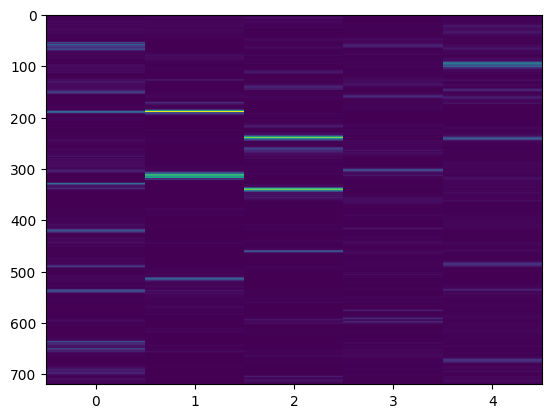

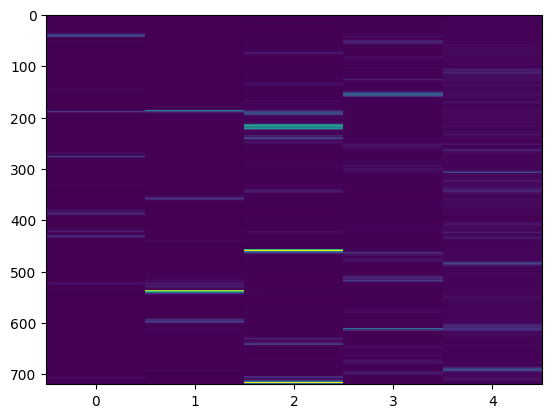

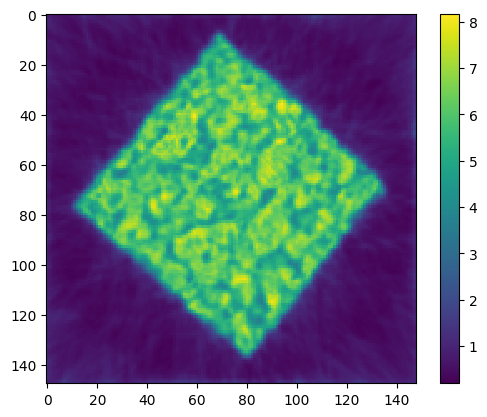

In [15]:
# reordering of the rows 6.8e13


prediction_cpu = prediction.get().reshape((N_Omega, Nx, N_eta, N_theta))
plt.imshow(prediction_cpu[20,90], aspect='auto', interpolation='nearest')
plt.show()
plt.imshow(arr[20,90], aspect='auto', interpolation='nearest')
plt.show()

plt.imshow(coeffs.sum(axis=-1), interpolation='nearest')
plt.colorbar()

In [16]:
idx = np.max(coeffs, axis=-1)   # descending

A_sorted = np.argmax(coeffs,axis=-1)
mask = coeffs.sum(axis=-1)>2
# mask[:,:10] = False
# mask[:,20:] = False
# mask[:65] = False
# mask[85:] = False
vals = A_sorted[:,:][mask]
freq = np.bincount(vals, minlength=5000)*1.0

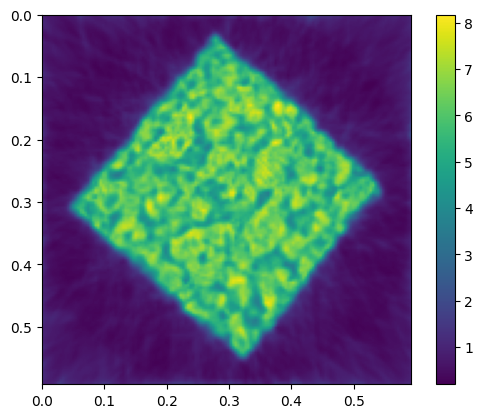

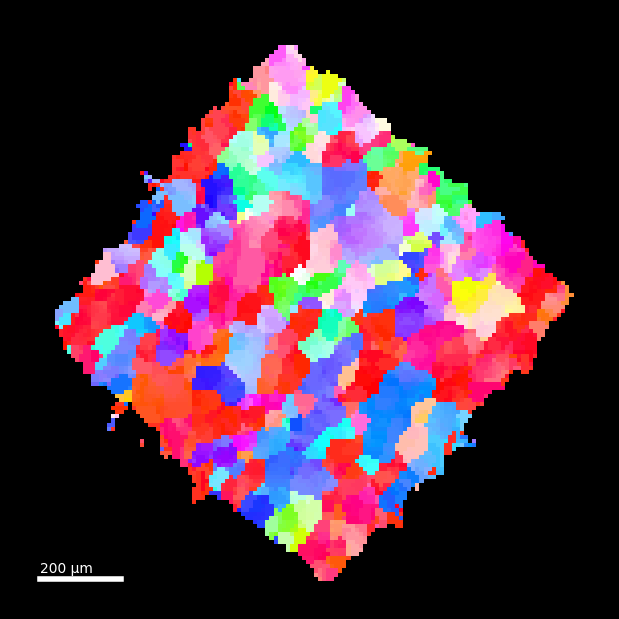

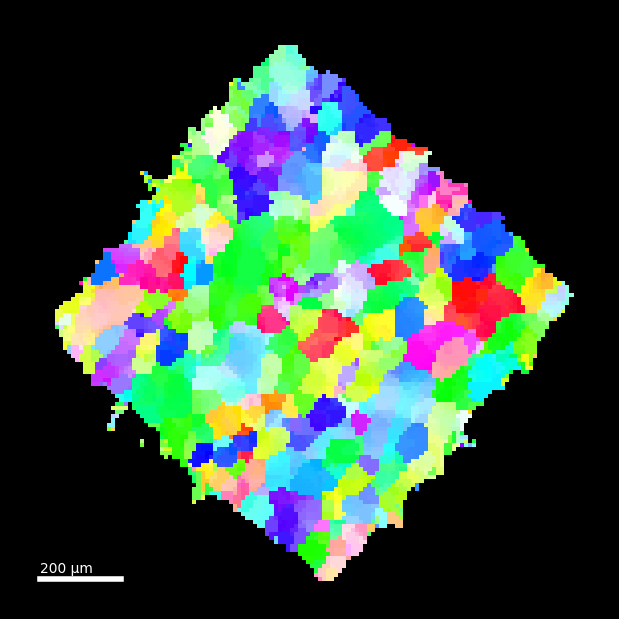

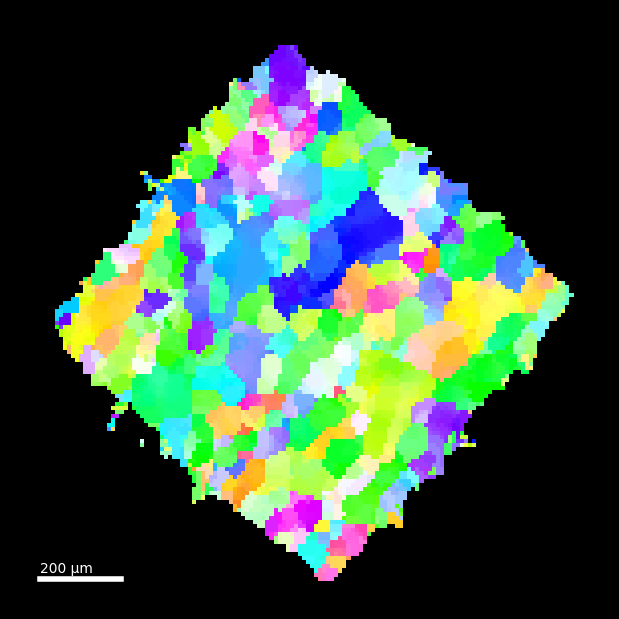

In [17]:
grid_sp = (grid.rotations_at_level(0))
grid_sp = Rot.concatenate(grid_sp)

stepsize = 0.004
imshow_opts = {'extent':(0, coeffs.shape[0]*stepsize, coeffs.shape[1]*stepsize, 0)}

plt.imshow(coeffs.sum(axis=2), **imshow_opts)
plt.colorbar()
plt.show()

IVP_map_direction = [0,0,1]
ipfkey = plot.IPFColorKeyTSL(symmetry.Oh, direction=Vector3d(IVP_map_direction))
orientations = Orientation.from_scipy_rotation(grid_sp)

orientations.symmetry = ipfkey.symmetry
rgb_z = ipfkey.orientation2color(orientations)[np.argmax(coeffs, axis = -1)]
mask = coeffs.sum(axis=2)>1
mask[:7] = False
mask[-7:] = False
mask[:,:7] = False
mask[:,-7:] = False
rgb_z[~mask] *= 0
fig, ax = plt.subplots(figsize=(6,6), facecolor='black')
ax.set_facecolor('black')

ax.imshow(rgb_z[::-1, ::-1],
          extent=(0, coeffs.shape[0]*stepsize,
                  coeffs.shape[1]*stepsize, 0))
ax.axis('off')

px_um, npx = 10, 20
L = npx*stepsize

x0 = 0.05*coeffs.shape[0]*stepsize
y0 = 0.95*coeffs.shape[1]*stepsize

ax.plot([x0, x0+L],[y0,y0],lw=4,color='w')
ax.text(x0, y0-0.03*coeffs.shape[1]*stepsize, f"{npx*px_um} µm",
        color='w', ha='left', va='top')

plt.tight_layout(pad=0)
plt.savefig('/work3/msaca/textomo_run_009/ipf_y.png', dpi=600)
plt.show()


IVP_map_direction = [0,1,0]
ipfkey = plot.IPFColorKeyTSL(symmetry.Oh, direction=Vector3d(IVP_map_direction))
orientations = Orientation.from_scipy_rotation(grid_sp)
orientations.symmetry = ipfkey.symmetry
rgb_z = ipfkey.orientation2color(orientations)[np.argmax(coeffs, axis = -1)]
rgb_z[~mask] *= 0
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6), facecolor='black')
ax.set_facecolor('black')

ax.imshow(rgb_z[::-1, ::-1],
          extent=(0, coeffs.shape[0]*stepsize,
                  coeffs.shape[1]*stepsize, 0))
ax.axis('off')

px_um, npx = 10, 20
L = npx*stepsize

x0 = 0.05*coeffs.shape[0]*stepsize
y0 = 0.95*coeffs.shape[1]*stepsize

ax.plot([x0, x0+L],[y0,y0],lw=4,color='w')
ax.text(x0, y0-0.03*coeffs.shape[1]*stepsize, f"{npx*px_um} µm",
        color='w', ha='left', va='top')

plt.tight_layout(pad=0)
plt.savefig('/work3/msaca/textomo_run_009/ipf_z.png', dpi=600)
plt.show()


IVP_map_direction = [1,0,0]
ipfkey = plot.IPFColorKeyTSL(symmetry.Oh, direction=Vector3d(IVP_map_direction))
orientations = Orientation.from_scipy_rotation(grid_sp)
orientations.symmetry = ipfkey.symmetry
rgb_z = ipfkey.orientation2color(orientations)[np.argmax(coeffs, axis = -1)]
rgb_z[~mask] *= 0
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6), facecolor='black')
ax.set_facecolor('black')

ax.imshow(rgb_z[::-1, ::-1],
          extent=(0, coeffs.shape[0]*stepsize,
                  coeffs.shape[1]*stepsize, 0))
ax.axis('off')

px_um, npx = 10, 20
L = npx*stepsize

x0 = 0.05*coeffs.shape[0]*stepsize
y0 = 0.95*coeffs.shape[1]*stepsize

ax.plot([x0, x0+L],[y0,y0],lw=4,color='w')
ax.text(x0, y0-0.03*coeffs.shape[1]*stepsize, f"{npx*px_um} µm",
        color='w', ha='left', va='top')

plt.tight_layout(pad=0)
plt.savefig('/work3/msaca/textomo_run_009/ipf_x.png', dpi=600)
plt.show()

In [ ]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

sym = symmetry.Oh
weights = coeffs.sum(axis=(0,1))
# weights[weights<10] = 0
# weights = freq

# -------- Reference orientations (your system) --------
O_ref = Orientation.from_matrix(R_5000_2)
O_ref.symmetry = sym

# -------- Permutations of coordinate axes --------
perms = list(itertools.permutations([0,1,2]))

# -------- IPF directions = sample axes --------
dirs = [
    Vector3d([0,0,1]),
    Vector3d([0,1,0]),
    Vector3d([1,0,0]),
]
titles = ["IPF-Z", "IPF-Y", "IPF-X"]

nrows = 1
ncols = 3

fig = plt.figure(figsize=(12, 3*nrows))


# ---------- Reference row ----------
for j, (v, title) in enumerate(zip(dirs, titles)):
    t = O_ref * v
    ax = fig.add_subplot(
        nrows, ncols, j+1,
        projection="ipf",
        symmetry=sym,
        direction=v
    )
    ax.pole_density_function(t, sigma=1.6, vmin=0, weights = weights, vmax = 3)
    ax.set_title(title)
    if j == 0:
        ax.set_ylabel("REF", rotation=0, labelpad=30, va="center")

plt.show()

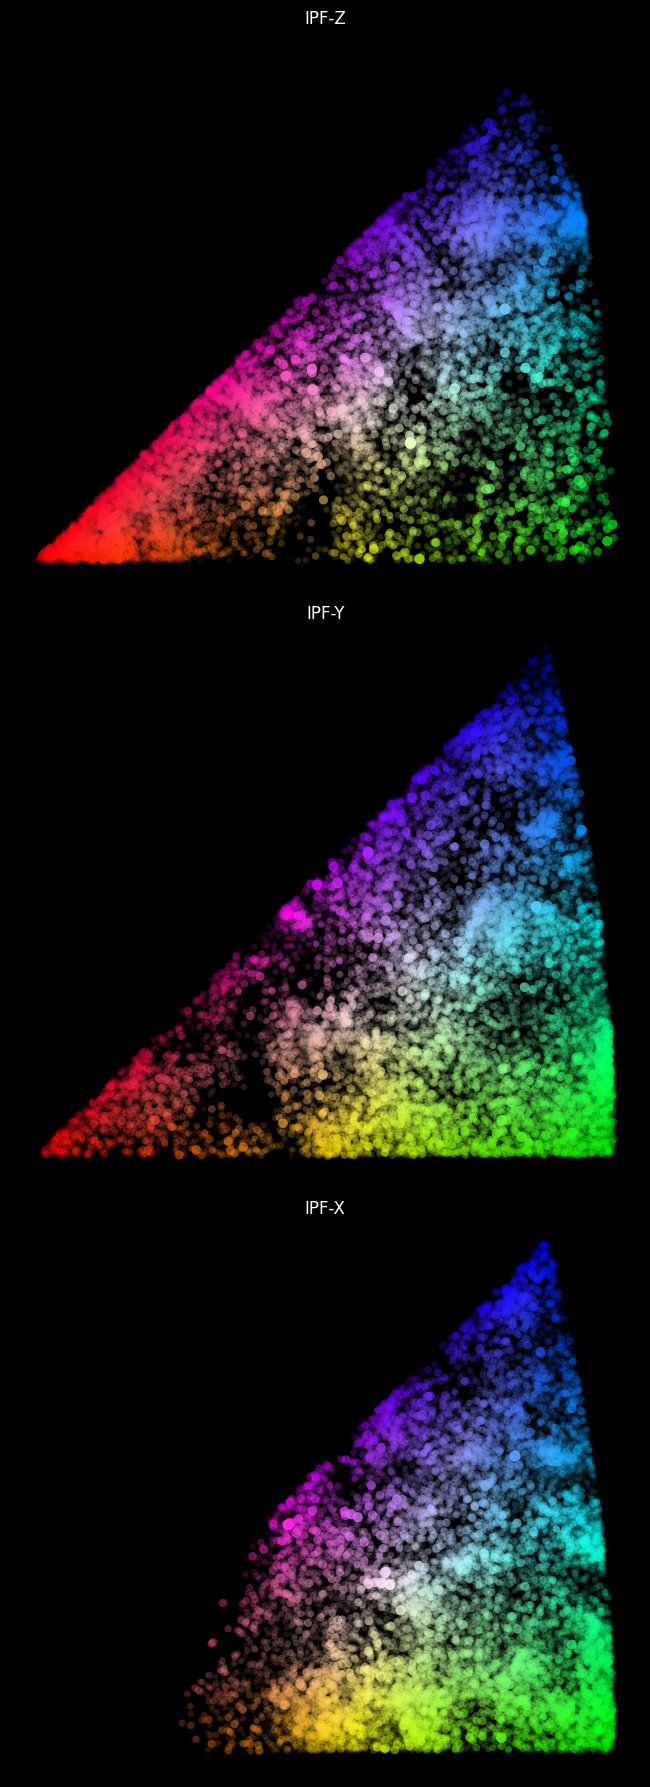

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d
from orix import plot

sym = symmetry.Oh

weights = coeffs.sum(axis=(0,1))
# weights = freq
w = weights.astype(float)

# normalize weights for plotting
w_norm = w / w.max()

# orientations
O = Orientation.from_matrix(R_5000_2)
O.symmetry = sym

dirs = [
    Vector3d([0,0,1]),
    Vector3d([0,1,0]),
    Vector3d([1,0,0]),
]
titles = ["IPF-Z", "IPF-Y", "IPF-X"]

fig, axes = plt.subplots(3, 1, figsize=(7,18), facecolor="black")

for i, (ax0, v, title) in enumerate(zip(axes, dirs, titles)):

    ax0.remove()
    ax = fig.add_subplot(3,1,i+1,
        projection="ipf",
        symmetry=sym,
        direction=v
    )

    ax.set_facecolor("black")

    ipfkey = plot.IPFColorKeyTSL(sym, direction=v)
    colors = ipfkey.orientation2color(O)

    sizes = 10 + 60 * w_norm          # point size
    alpha = 0.01 + 0.99 * (w_norm)     # transparency


    ax.scatter(
        O,
        c=colors,
        s=sizes,
        alpha=alpha,
        edgecolors="none"
    )

    ax.set_title(title, color="white")

plt.tight_layout()
plt.show()



Status:

The sample axes in the config file have been switched around and are now chosen in such a way that the IPF maps qualitatively those in the DANMAX.pdf file without axis permutations. For the detector coordinates I have tried permuting in different ways. Some of them gave a clearly wrong result (which I found out by observing the loss decrease when running te optimization). And some permutations gave good results. I think there are more than one good choice as some of them probably are equivalent modulo the cubic point group...

I have different ways of generating orientation grids:
- Uniform hopf grid
- Uniform random sampling (works well for many grid points)
- The orientations that Axel provided

There are different ways of pruning these grids. For the uniform random sampling and for Axel's grid, I pruned the grid by extracting a subgrid where no orientations can be closer than x degrees to each other. I set this minimal distance to 0.8 degrees, and this allows me to extract around 5000 orientations from Axels grid and at least 5000 from the random-uniform grid (I stop at 5000).

I try fitting the model to each of these grids. First with low sigma: 0.01 radians=0.573 degrees. The loss for fitting withthe random-uniform loss quickly decreases, and the IPF maps look qualitatively similar the those in the DANMAX document. For Axel's grid we see some decrease in the loss between iterations, but it plateaus at a higher value. The IPF maps look strange, however the scatter plots look similar to those in the DANMAX.pdf document.
I tried with higher values of sigma, sigma=0.03, and I get roughly the same results.

Here is some idea about what could be wrong:
